In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from scipy.stats import uniform, norm, multivariate_normal
import seaborn as sns 
import multiprocessing as mp
from functools import partial
import time
import copy
import glob
import warnings
warnings.filterwarnings('ignore')

import pymc as pm
from main_pool import Main
from calibr_funcs import plot_results

from networks.model_output import SEIRModelOutput, SEIRParams
from networks.SEIR_network import SEIRNetworkModel

from hybrid_network_to_seir import NetworkSEIR_tuned,\
                                    generate_synthetic_data

#pip install -e git+https://github.com/Mpkosh/Mathematics-of-Epidemics-on-Networks.git@my_changes#egg=eon

import plot_funcs
import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day
%load_ext autoreload
%autoreload 2

pm.__version__  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'5.25.1'

## stuff

In [17]:
# generate synthetic data with known parameters for testing
true_tau = 0.1
true_alpha = 0.95
init_inf = 0.0001
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate

days=range(1, 150)
data_p = 'new_network_check/'
'''
observed_data = generate_synthetic_data(alpha=true_alpha, lmbd=true_lmbd, 
                                        days=days, data_path=data_p,
                                       with_seirb=True, with_switch=False,
                                       for_observed=True)
'''

'''
self.G = nx.barabasi_albert_graph(population=10**5, 5)
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate
init_inf_frac = 1e-4 # fraction of initially infected

alpha = 0.95
beta = 0.1
'''


'\nself.G = nx.barabasi_albert_graph(population=10**5, 5)\ngamma = 0.3 # latent period rate\ndelta = 0.2 # recovery rate\ninit_inf_frac = 1e-4 # fraction of initially infected\n\nalpha = 0.95\nbeta = 0.1\n'

In [18]:
pot = glob.glob('../new_sw_100000/'+
            f'p_{true_tau}_{gamma}_{delta}_{init_inf}_{true_alpha}*')

pot

['../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_0.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_1.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_2.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_3.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_4.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_5.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_6.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_7.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_8.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_9.csv']

In [46]:
path = '../new_sw_100000\\p_0.5799999999999997_0.3_0.2_0.0001_0.8000000000000005_seed_0.csv'
seed_df = pd.read_csv(path, usecols=['E','S'])
# calculating incidence
temp = seed_df[['E','S']].shift([0,1])
seed_df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                    (temp['S_0'] - temp['S_1'])
seed_df['incidence'].fillna(0, inplace=True)
seed_df

,S,E,incidence
0,79991,0,0.0
1,79990,1,0.0
2,79988,3,0.0
3,79987,2,2.0
4,79981,4,4.0
...,...,...,...
145,4069,160,54.0
146,4044,139,46.0
147,4014,125,44.0
148,3993,113,33.0


In [49]:
#seed_df[['incidence']].to_csv('incidence_sw.csv', 
                             index=False)


In [128]:
q = glob.glob('../new_sw_100000/*.csv')[::10]
import random
random.seed(42)
random.sample(q,10)

['../new_sw_100000\\p_0.7499999999999997_0.3_0.2_0.0001_0.5800000000000003_seed_0.csv',
 '../new_sw_100000\\p_0.20999999999999996_0.3_0.2_0.0001_0.5200000000000002_seed_0.csv',
 '../new_sw_100000\\p_0.13999999999999999_0.3_0.2_0.0001_0.6400000000000003_seed_0.csv',
 '../new_sw_100000\\p_0.8499999999999996_0.3_0.2_0.0001_0.9400000000000006_seed_0.csv',
 '../new_sw_100000\\p_0.3799999999999999_0.3_0.2_0.0001_0.3300000000000001_seed_0.csv',
 '../new_sw_100000\\p_0.34999999999999987_0.3_0.2_0.0001_0.2700000000000001_seed_0.csv',
 '../new_sw_100000\\p_0.3199999999999999_0.3_0.2_0.0001_0.8800000000000006_seed_0.csv',
 '../new_sw_100000\\p_0.23999999999999994_0.3_0.2_0.0001_0.4300000000000002_seed_0.csv',
 '../new_sw_100000\\p_0.8499999999999996_0.3_0.2_0.0001_0.5300000000000002_seed_0.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.5900000000000003_seed_0.csv']

## work

In [3]:
'''
'../new_sw_100000\\p_0.5799999999999997_0.3_
0.2_0.0001_0.8000000000000005_seed_0.csv'
'''

true_tau = 0.1
true_alpha = 0.95

init_inf = 1e-4
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate

days=range(1, 150)

In [4]:
file='data_ba_100000.csv'
d = pd.read_csv(file, index_col=0)#.iloc[::10]
if 'init_rec_frac' in d.columns:
    d.rename(columns={'init_rec_frac':'alpha'}, inplace=True)
d.drop(columns=['gamma','delta','init_inf_frac'], inplace=True)
s = 150


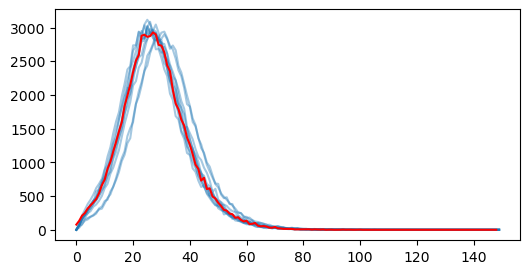

In [5]:
plt.subplots(figsize=(6,3))

observed_data = pd.read_csv('incidence_synthetic_curve.csv')
observed_data.columns=['incidence']

beta_arr = np.arange(0.1, 1, 0.01) #np.arange(0.04, 0.09, 0.01)
alpha_arr = np.arange(0.2, 1, 0.01) #np.arange(0.005, 0.011, 0.001)

i = 0
results=[]
for beta in beta_arr:
    beta = round(beta,2)
    for alpha in alpha_arr:
        alpha = round(alpha,2)
        #print(chosen.iloc[:,:2].values, beta, alpha)


        if (beta==true_tau)&(alpha==true_alpha):
            incidence = d.iloc[i*10:i*10+10,2:].values#.mean()
            for i in range(10):
                plt.plot(incidence[i], color='tab:blue',
                        alpha=0.4, label='')
        i+=1
plt.plot(observed_data,color='red')

In [119]:
q.shape

(150,)

np.float64(166.16257099599778)

In [6]:
# create
network_params = {'n_nodes': 100000,
                  'network_type': 'ba'}
#observed_prv = observed_data[['incidence']]
hn = NetworkSEIR_tuned(observed_data, network_params,
                       fixed_sigma=gamma, 
                       fixed_gamma=delta)

'''

true_tau = 0.1
true_alpha = 0.95
'''
# define parameter ranges for priors
prior_ranges = {"tau": (0.57, 0.59),  
                "alpha": (0.79, 0.81) 
                }

start_time = time.time()
# run History Matching
hm_results = hn.history_matching(prior_ranges, 
                                 n_samples=7200,
                                 adaptive=True, 
                                 accept_ratio=.02,
                                 prepared=True, 
                                 folder='../hybrid_surrogate/sim_data/new_sw_100000/',
                                 file = 'data_ba_100000.csv')
end_time = time.time()

print('It took: ', end_time - start_time)

Network SEIR - Fixed parameters: sigma = 0.3, gamma = 0.2
Calibrating parameters
Running Network SEIR history matching with 7200 samples...
Accepted 144 parameter sets
It took:  5.4123735427856445


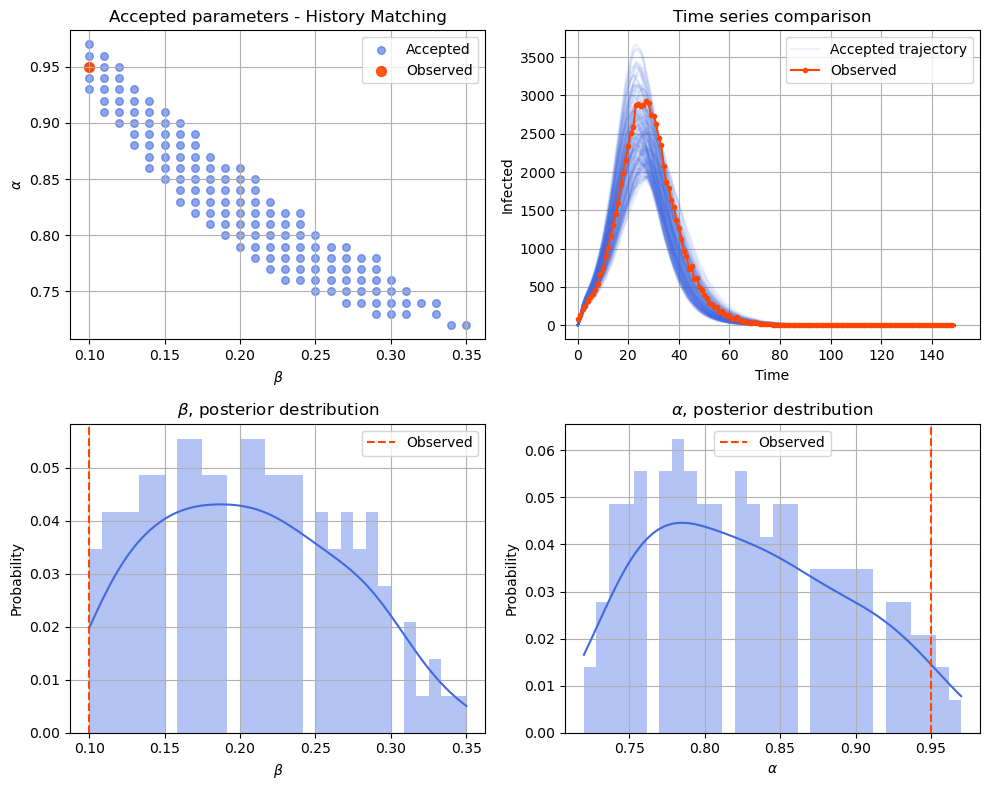

In [7]:
plot_results(observed_data, hm_results, 
             "History Matching", n_trajectories=len(hm_results),
             true_p0=true_tau, true_p1=true_alpha)

plt.savefig(f'results/hmba.pdf', format='pdf', bbox_inches='tight')

In [8]:
hm_results['tau'].quantile(.01), hm_results['tau'].quantile(.99)

(np.float64(0.1), np.float64(0.33569999999999994))

In [9]:
hm_results['tau'].min(), hm_results['tau'].max()

(np.float64(0.1), np.float64(0.35))

In [10]:
hm_results['alpha'].quantile(.01), hm_results['alpha'].quantile(.99)

(np.float64(0.7242999999999999), np.float64(0.96))

In [11]:
def switch_seir(sim_data, gamma=0.1, delta=0.08,
                frac=0.01, modeling_duration=249, 
                method='expanding'):
    
    pop = sim_data.iloc[0,:4].sum()
    '''
    switches = sim_data[sim_data['I'] > pop*frac]
    
    if switches.shape[0]:
        switch_day = switches.index[0]
    else:
        switch_day = 7
    '''
    
    switch_day = sim_data.shape[0]-1
    #print(switch_day)
    y0 = sim_data.iloc[switch_day,:4].values.flatten()
    # FOR FULL OBSERVED DATA
    ts = np.arange(modeling_duration-switch_day)
    if method=='expanding':
        beta = sim_data.iloc[:switch_day]['Beta'
                                ].expanding(1).mean().values[-1]
    elif method=='last':
        beta = sim_data.iloc[:switch_day]['Beta'].values[-1]
    elif method=='rolling':
        beta = sim_data.iloc[:switch_day]['Beta'
                                ].rolling(7).mean().values[-1]

    # Median from HM accepted parameters' trajectories!
    #median_b = pd.read_csv('median_beta.csv')
    #beta = median_b.iloc[switch_day:].values
    S,E,I,R = seir_discrete.seir_model(y0, ts, beta, 
                                       gamma, delta, stype='d', 
                                       beta_t=False).T

    fin = pd.DataFrame([S,E,I,R]).T
    fin.columns = ['S','E','I','R']

    fin['Beta'] = beta
    fin['day'] = ts+switch_day
    fin = pd.concat([sim_data.iloc[:switch_day], fin]
                   ).reset_index(drop=True)
    return fin

In [12]:
def simulation_func(rng, tau, alpha, modeling_duration, 
                    with_switch=False, num_runs=[1], 
                    frac=[0.01], size=None):
    
    tau = np.array(tau).flatten()[0]
    alpha = np.array(alpha).flatten()[0]
    
    modeling_duration = np.array(modeling_duration).flatten()[0]
    num_runs = np.array(num_runs).flatten()[0] 
    frac = np.array(frac).flatten()[0] 
    
    method='last'
    network_type='ba'    
    gamma = 0.3
    delta=0.2
    n_nodes=100000
    
    chosen_seed = np.random.RandomState(42)
    network_model = SEIRNetworkModel(n_nodes, network_type, 
                                     chosen_seed)
    init_inf_frac = 0.0001
    init_rec_frac = 1 - alpha

    all_results = []
    for run in range(np.array(num_runs).flatten()[0]):
        res,rt,ri = network_model.simulate(beta=tau, gamma=gamma, delta=delta, 
                                     init_inf_frac=init_inf_frac, 
                                     init_rec_frac=init_rec_frac,
                                     tmax=modeling_duration,
                                     I_frac_switch=frac,
                                     frac_pop='Incidence'
                                    )
        
        seed_df = pd.DataFrame([res.S, res.E, res.I, res.R]).T
        seed_df.columns = ['S','E','I','R']
        seed_df['day'] = np.arange(seed_df.shape[0])
        # use "values", because "iloc" saves index info 
        # and messes with the calculation
        beta_calc = - seed_df.S.diff().values[1:] / (
                                seed_df.S.values[:-1] * seed_df.I.values[:-1]
                                )
        # the last Beta value cannot be calculated: no S_{t+1}
        seed_df['Beta'] = [*beta_calc, 0] 
        s = seed_df.shape[0]
        seed_df.fillna(0, inplace=True)
        if np.array(with_switch).flatten()[0]:
            if 'Beta' not in seed_df.columns:
                print(seed_df.columns)
            seed_df = switch_seir(seed_df, gamma=gamma, delta=delta,
                                  frac=np.array(frac).flatten()[0], 
                                  modeling_duration=modeling_duration, 
                                  method=method)

        # calculating incidence
        temp = seed_df[['E','S']].shift([0,1])
        seed_df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                            (temp['S_0'] - temp['S_1'])
        #print(seed_df.iloc[s-5:s+2])
        seed_df['incidence'].fillna(0, inplace=True)
        all_results.append(seed_df)    

    if all_results:
        combined_results = pd.concat(all_results, 
                                     ignore_index=True)
        seed_df = combined_results.groupby('day').mean().reset_index()
        seed_df[['S','E','I','R',
                    'incidence']] = seed_df[['S','E','I','R',
                                             'incidence']].round()
    
    #print(seed_df['incidence'].astype(int))
    res = seed_df['incidence'].astype(int).values
    #res = stz(res)
    return res
    

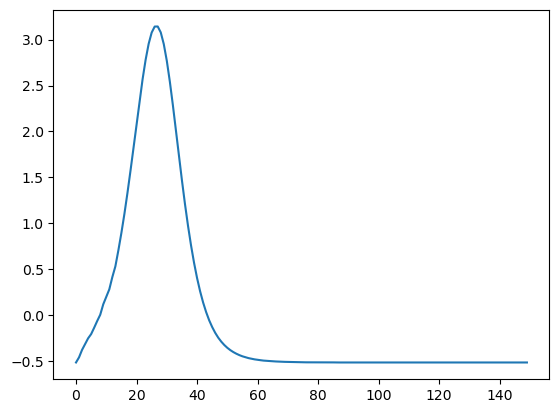

In [96]:
def stz(series):
    """Standardize a pandas series"""
    return (series - series.mean()) / series.std()

q.mean(), q.std()
plt.plot(stz(q)* q.std() + q.mean())

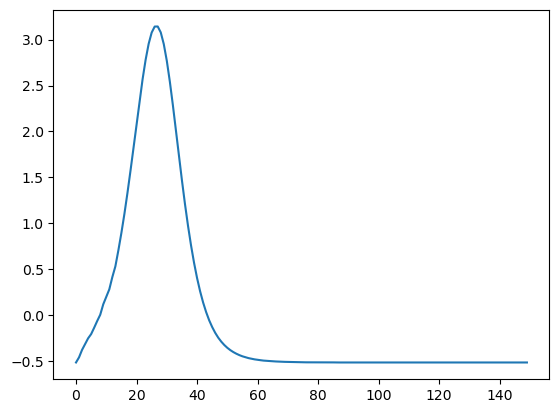

In [97]:
from sklearn import preprocessing

sc = preprocessing.StandardScaler()
qs = sc.fit_transform(q.reshape(-1, 1))
plt.plot(qs)

CPU times: total: 6.36 s
Wall time: 6.39 s


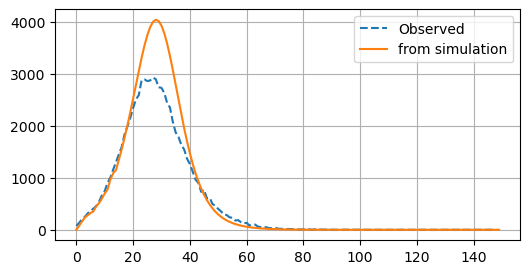

In [121]:
%%time
# 0.1, 0.95
q = simulation_func(_, tau=[0.1], alpha=[0.95], 
                    modeling_duration=[150], 
                    with_switch=True, num_runs=[1], 
                    frac=[.01], size=None)

plt.subplots(figsize=(6,3))
plt.plot(observed_data.incidence, ls='--', label='Observed')
plt.plot(q, label='from simulation')

plt.grid()
plt.legend()

In [149]:
hm_results.head()

,tau,alpha,distance,trajectory
390,0.14,0.90,1852.921208,"[0.0, 74.1, 185.5, 251.2, 307.8, 367.1, 434.3,..."
154,0.11,0.94,1904.849597,"[0.0, 64.4, 167.5, 228.9, 292.4, 353.1, 414.4,..."
232,0.12,0.92,2316.348591,"[0.0, 68.2, 167.7, 234.6, 289.8, 358.7, 400.8,..."
311,0.13,0.91,2861.417718,"[0.0, 70.2, 177.3, 254.1, 332.1, 389.9, 447.6,..."
75,0.10,0.95,3448.692349,"[0.0, 65.2, 149.8, 211.9, 266.7, 321.7, 375.3,..."


In [172]:
8*60*60/40

720.0

In [15]:
# 85 sec for 5x2, frac=0.01

draws = 4
chains = 3
progressbar = True

'''

'''

with_switch=np.array(True) 
num_runs=[1]
frac=[0.01]
gamma = 0.3
delta=0.2
n_nodes=100000


with pm.Model() as pm_model:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    
    p0_v = pm.Uniform(name="tau", 
                      lower=hm_results['tau'].min(),#quantile(.01), 
                      upper=hm_results['tau'].max()#quantile(.99)
                     )
    p1_v = pm.Uniform(name="alpha", 
                      lower=hm_results['alpha'].min(),#quantile(.01), 
                      upper=hm_results['alpha'].max()#quantile(.99)
                     )
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = len(observed_data) #249
    

    sim = pm.Simulator("sim", simulation_func, 
                        params = (p0_v, p1_v, modeling_duration, 
                                  with_switch, num_runs, frac
                                 ),   
                       
                        epsilon=2000, 
                        ndims_params=[1,1,1,1,1,1],
                        observed=observed_data['incidence'].values
                      )
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idata = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=6, chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()
    
    idata.extend(pm.sample_posterior_predictive(idata,
                                            progressbar=progressbar))

    

# ~40-50 sec per sample
# 4472sec, 2x100, frac=0.01
print('It took ', end_time-start_time, 'sec')

Initializing SMC sampler...
Sampling 3 chains in 3 jobs


The number of samples is too small to check convergence reliably.
Sampling: [sim]


It took  201.56999683380127 sec


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,0.170,0.056,0.122,0.334,0.016,0.019,13.0,13.0,1.01
alpha,0.864,0.040,0.757,0.908,0.011,0.011,13.0,13.0,1.04


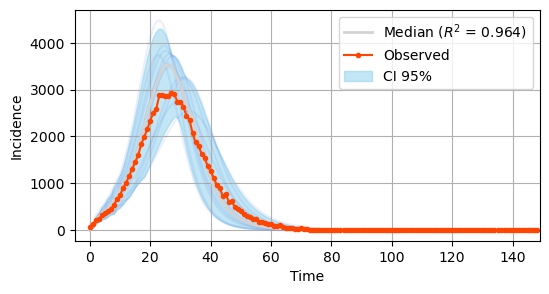

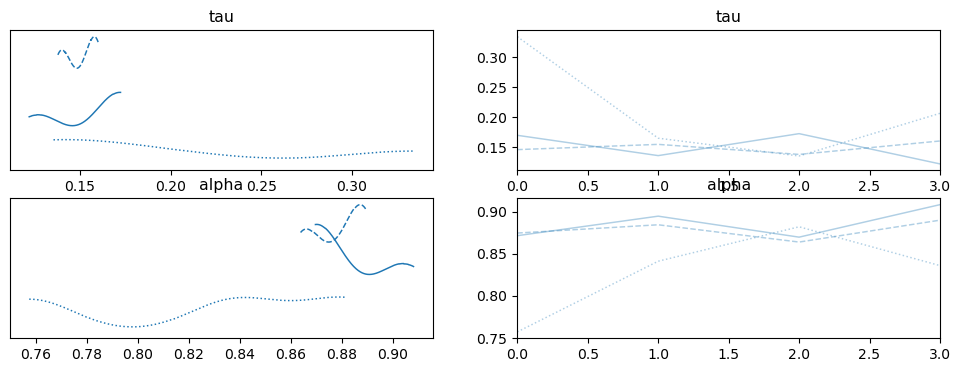

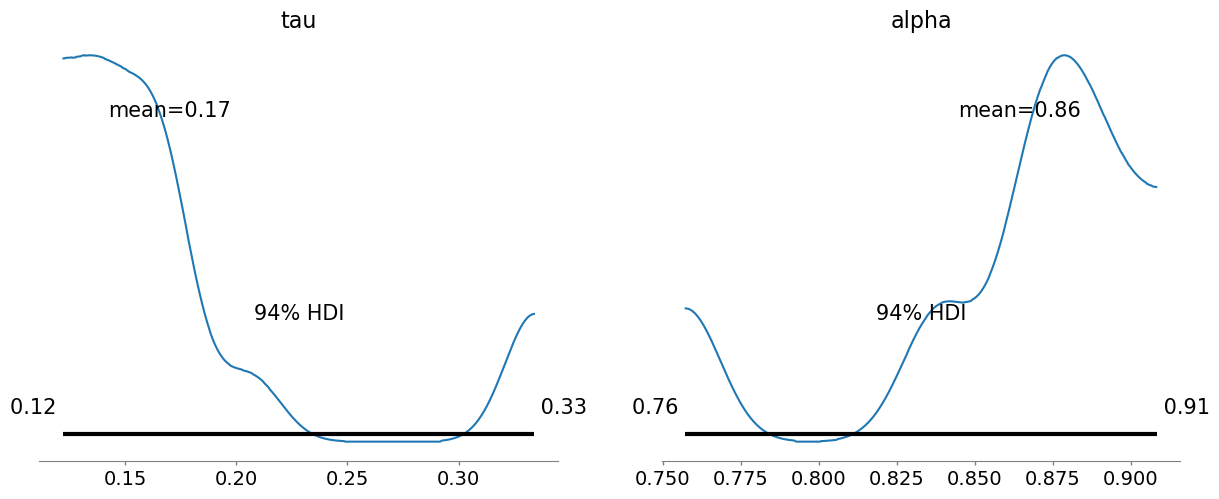

In [16]:
plot_funcs.plots(idata, observed_data['incidence'].values, '', 
                 for_pred=False, with_trace=True)


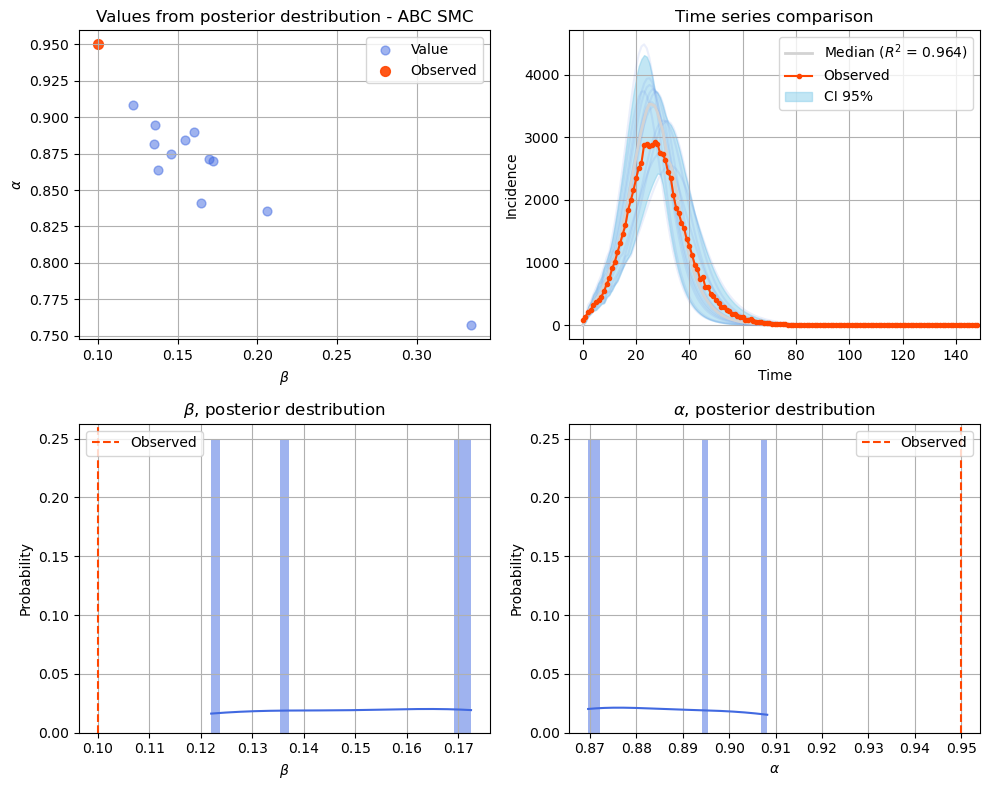

In [17]:
plot_funcs.results_calib(observed_data, idata, 
                         true_tau, true_alpha)
plt.savefig(f'results/ba_calib.pdf', format='pdf', bbox_inches='tight')

In [ ]:
# 85 sec for 5x2, frac=0.01

draws = 3
chains = 4
progressbar = True

'''

'''

with_switch=np.array(False) 
num_runs=[1]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000


with pm.Model() as pm_model:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    
    p0_v = pm.Uniform(name="tau", 
                      lower=hm_results['tau'].min(),#quantile(.01), 
                      upper=hm_results['tau'].max()#quantile(.99)
                     )
    p1_v = pm.Uniform(name="alpha", 
                      lower=hm_results['alpha'].min(),#quantile(.01), 
                      upper=hm_results['alpha'].max()#quantile(.99)
                     )
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = len(observed_data) #249
    

    sim = pm.Simulator("sim", simulation_func, 
                        params = (p0_v, p1_v, modeling_duration, 
                                  with_switch, num_runs, frac
                                 ),   
                       
                        epsilon=2000, 
                        ndims_params=[1,1,1,1,1,1],
                        observed=observed_data['incidence'].values
                      )
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idata2 = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=6, chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()
    
    idata2.extend(pm.sample_posterior_predictive(idata,
                                            progressbar=progressbar))

    

# ~40-50 sec per sample
# 4472sec, 2x100, frac=0.01
print('It took ', end_time-start_time, 'sec')

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


In [ ]:
plot_funcs.plots(idata2, observed_data['incidence'].values, '', 
                 for_pred=False, with_trace=True)


In [ ]:
plot_funcs.results_calib(observed_data, idata2, 
                         true_tau, true_alpha)

## old

In [61]:
# 85 sec for 5x2, frac=0.01

draws = 200
chains = 3
progressbar = True

'''

'''

with_switch=np.array(True) 
num_runs=[2]
frac=[0.01]
gamma = 0.3
delta=0.2
n_nodes=100000


with pm.Model() as pm_model:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    
    p0_v = pm.Uniform(name="tau", 
                      lower=hm_results['tau'].quantile(.01), 
                      upper=hm_results['tau'].quantile(.99)
                     )
    p1_v = pm.Uniform(name="alpha", 
                      lower=hm_results['alpha'].quantile(.01), 
                      upper=hm_results['alpha'].quantile(.99)
                     )
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = len(observed_data) #249
    

    sim = pm.Simulator("sim", simulation_func, 
                        params = (p0_v, p1_v, modeling_duration, 
                                  with_switch, num_runs, frac
                                 ),   
                       
                        epsilon=3000, 
                        ndims_params=[1,1,1,1,1,1],
                        observed=observed_data['incidence'].values)
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idata = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=6, chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()
    
    idata.extend(pm.sample_posterior_predictive(idata,
                                            progressbar=progressbar))


# 10.5sec, 2x2, frac=0.001    
# 4472sec, 2x100, frac=0.01
print('It took ', end_time-start_time, 'sec')

Initializing SMC sampler...
Sampling 3 chains in 3 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [sim]


It took  15549.978916406631 sec


[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\importlib\__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,0.288,0.099,0.122,0.465,0.004,0.002,511.0,516.0,1.00
alpha,0.804,0.082,0.678,0.953,0.004,0.002,494.0,439.0,1.01


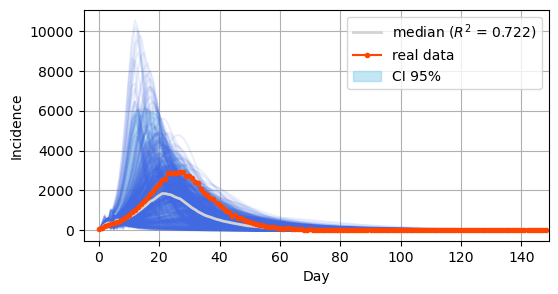

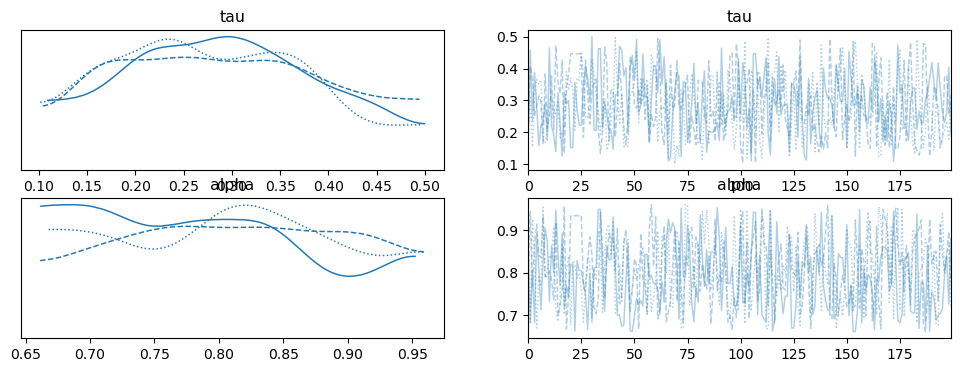

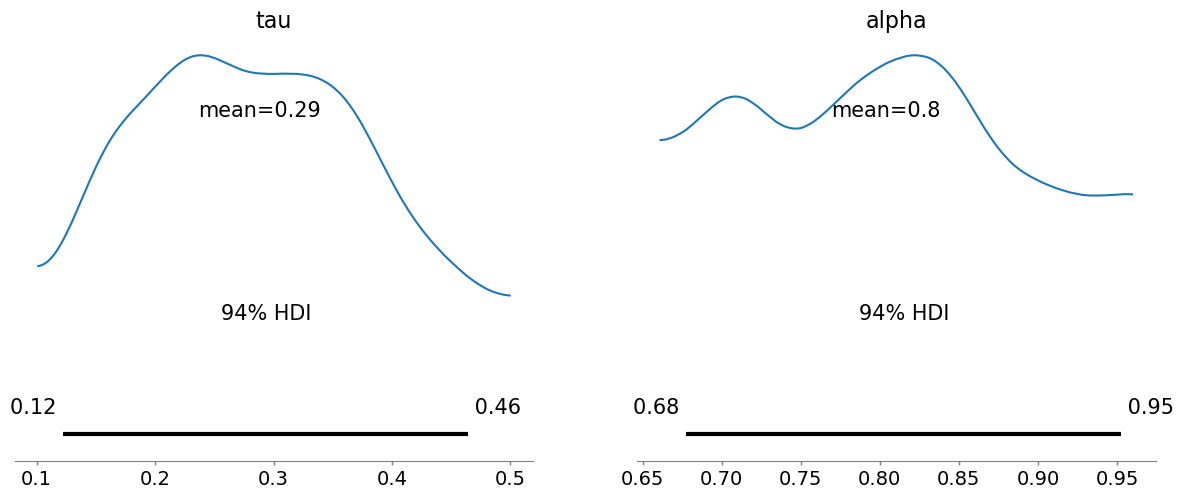

In [62]:
plot_funcs.plots(idata, observed_data['incidence'].values, '', 
                 simulation_func, for_pred=False, with_trace=True)


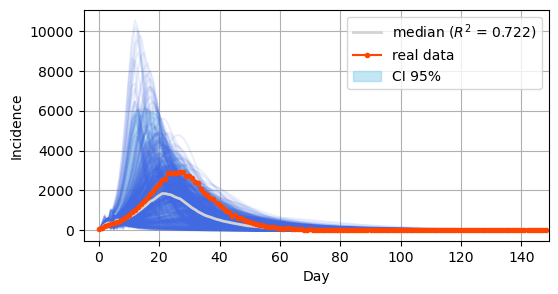

In [63]:
plot_funcs.plots(idata, observed_data['incidence'].values, '', 
                 simulation_func, for_pred=False, with_trace=False)
plt.savefig(f'results/ba_calib.pdf', format='pdf', bbox_inches='tight')

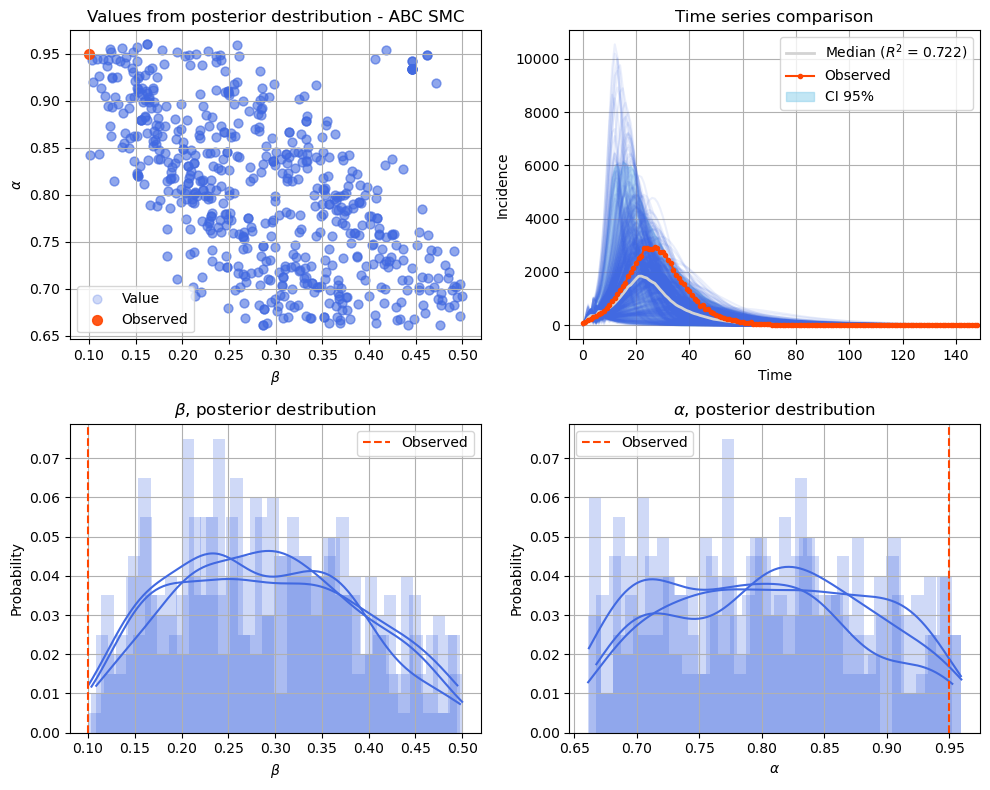

In [65]:
plot_funcs.results_calib(observed_data, idata, 
                         true_tau, true_alpha)
plt.savefig(f'results/ba_calib.pdf', format='pdf', bbox_inches='tight')

In [66]:
idata.posterior.to_netcdf('ba_p.h5', engine='scipy')
idata.posterior_predictive.to_netcdf('ba_pp.h5', engine='scipy')

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\importlib\__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,0.743,0.089,0.596,0.927,0.013,0.006,46.0,71.0,1.18
alpha,0.796,0.053,0.708,0.869,0.008,0.004,45.0,31.0,1.06


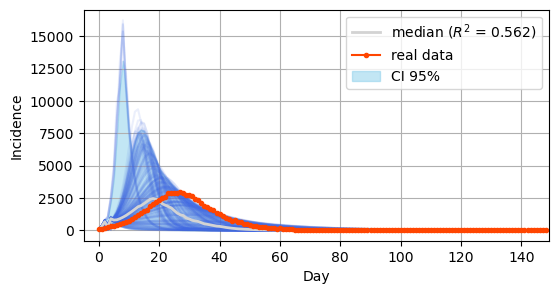

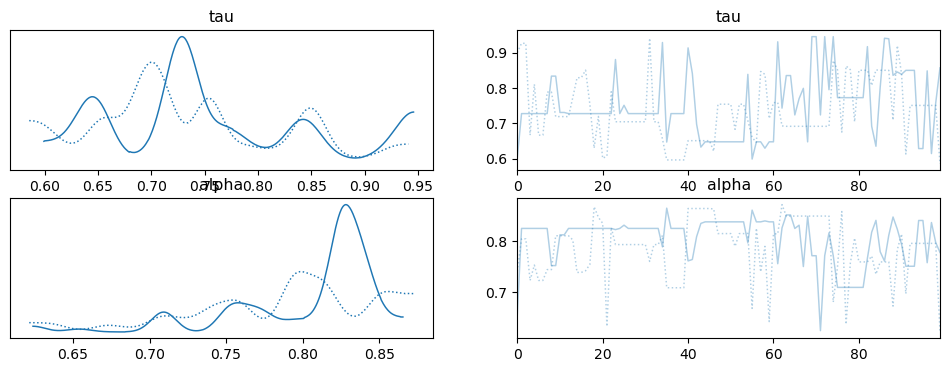

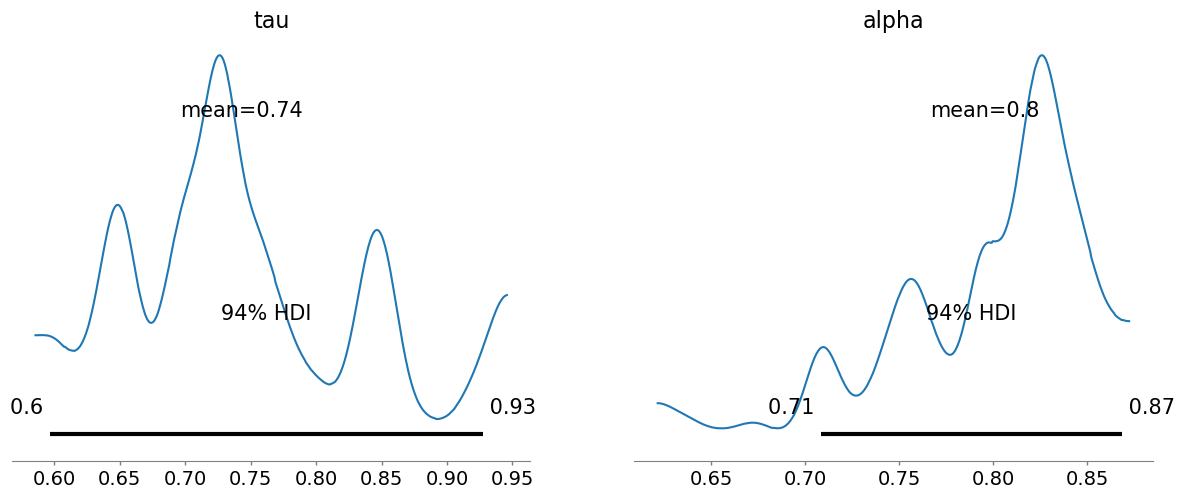

In [59]:
plot_funcs.plots(idata, observed_data['incidence'].values, '', 
                 simulation_func, for_pred=False, with_trace=True)
